# CDA6: Wavenumber-Frequency Analysis of Equatorial Waves

This notebook introduces the theoretical foundations and practical application of wavenumber-frequency analysis, a technique pioneered by **Wheeler and Kiladis (1999)**. This method revolutionized tropical meteorology by providing a robust way to identify and isolate equatorially trapped waves from observational data.

### The Conceptual Framework

The tropical atmosphere is fundamentally different from the mid-latitudes. Because the Coriolis force vanishes at the equator, geostrophic balance breaks down. Instead of weather systems driven by baroclinic instability (like mid-latitude fronts), the tropics are dominated by convective systems organized by large-scale, equatorially trapped waves.

These waves act like drumheads vibrating in specific, predictable patterns. They propagate horizontally along the equator but their amplitude decays rapidly as you move poleward, hence the term "equatorially trapped." 

Before 1999, these waves were mathematically predicted and occasionally spotted in station data, but isolating them globally was difficult because the atmosphere is inherently noisy. Wheeler and Kiladis realized that if you convert a long record of gridded satellite data (like cloud cover or precipitation) from the **space-time domain** (longitude and time) into the **wavenumber-frequency domain** using a 2D Fast Fourier Transform (FFT), the spectral peaks of the data align perfectly with the theoretical wave patterns predicted decades earlier.

This analysis technique thus builds on the FFT (and wavelet/EOF) lessons we covered earlier. 

First of all let's install the packages that we need


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

### The Mathematical Foundation: Matsuno (1966)

To understand where the wave curves come from, we must look at the work of Taroh Matsuno. He modeled the tropical atmosphere using the **Shallow Water Equations** on an **Equatorial Beta Plane**. 

The equatorial beta plane approximation linearizes the Coriolis parameter `f` near the equator, setting $f = \beta y$, where $\beta$ is the meridional gradient of the Coriolis parameter and `y` is the distance from the equator.

The linearized shallow water equations without friction or forcing are:

**1. Zonal Momentum:**
$$\frac{\partial u}{\partial t} - \beta y v = -g \frac{\partial \eta}{\partial x}$$

**2. Meridional Momentum:**
$$\frac{\partial v}{\partial t} + \beta y u = -g \frac{\partial \eta}{\partial y}$$

**3. Continuity (Mass Conservation):**
$$\frac{\partial \eta}{\partial t} + H \left( \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} \right) = 0$$

Where:
* $u$ and $v$ are zonal and meridional velocities.
* $\eta$ is the perturbation height (like a pressure anomaly).
* $H$ is the equivalent depth of the fluid (a measure of vertical stratification).
* $g$ is acceleration due to gravity.

Matsuno assumed solutions in the form of waves propagating zonally (east-west):
$$u, v, \eta \propto e^{i(kx - \omega t)}$$

Where $k$ is the zonal wavenumber and $\omega$ is the angular frequency. By substituting this wave solution into the equations and solving for the meridional boundary condition that amplitude must go to zero at the poles ($v \rightarrow 0$ as $y \rightarrow \pm \infty$), Matsuno arrived at a single governing equation: the **Dispersion Relation**.

Non-dimensionalizing the terms yields the famous cubic equation:

$$\omega^2 - k^2 - \frac{k}{\omega} = 2n + 1$$

Here, $n$ is the meridional mode integer ($n$ = 0, 1, 2...). This equation dictates exactly how fast a wave of a certain size can travel in the tropics.

### Symmetry, Antisymmetry, and the Meridional Mode ($n$)

The integer $n$ in Matsuno's equation determines the structure of the wave across the equator. 

Because the Coriolis force changes sign at the equator, the wave solutions are mathematically grouped into two categories based on their structure around the equator:
* **Symmetric Modes ($n$ = 1, 3, 5...):** The height field ($\eta$) and zonal wind ($u$) are symmetric across the equator (e.g., same sign at 10N and 10S). Equatorial Rossby (ER) waves and Kelvin waves fall into this category.
* **Antisymmetric Modes ($n$ = 0, 2, 4...):** The height field and zonal wind are antisymmetric across the equator (e.g., opposite signs at 10N and 10S). Mixed Rossby-Gravity (MRG) waves fall here.

**The Wheeler-Kiladis Innovation:**
To make these theoretical waves pop out in noisy observational data, Wheeler and Kiladis separated the raw satellite data into Symmetric and Antisymmetric components *before* doing the FFT.

* Symmetric Component = 0.5 * (Northern Hemisphere + Southern Hemisphere)
* Antisymmetric Component = 0.5 * (Northern Hemisphere - Southern Hemisphere)

This brilliantly isolates the specific wave families, preventing them from bleeding together in the final power spectrum.

### Artificial Dataset

Before we start to apply the technique to real data of precipitation or OLR, we are going to invent an artificial dataset as usual, so that we "*know*" what the answer is and thus can validate the code.

The field will consist of a propagating cosine wave on which we will add some white noise.  Let's do this and plot the raw field. 

In [19]:
import numpy as np

# Create artificial grid for a basic 2D FFT demonstration
nlon = 360  # 1 degree pretend resolution 
ntime = 365 # like having 365 days...

lon = np.linspace(0, 360, nlon, endpoint=False)
time = np.arange(ntime)
Lon, Time = np.meshgrid(lon, time)

time

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

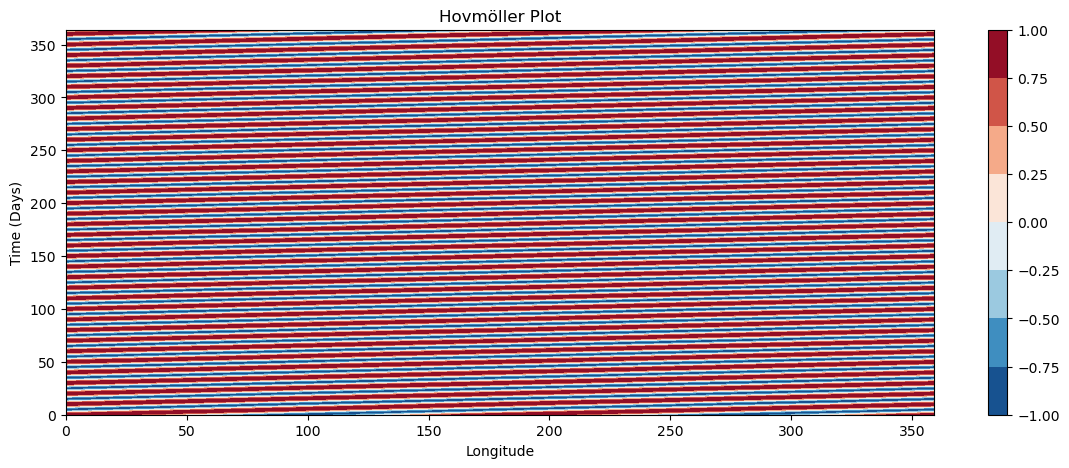

In [36]:
# Wave parameters: Wavenumber 3, Frequency 0.1 cycles/day
k_zonal = 2 ### SPACE!!!
freq = 0.1  ### TIME!!!

# Generate the field and add noise
field = np.cos(k_zonal * (Lon * np.pi / 180) - 2 * np.pi * freq * Time)

# Plot
def hovplot(field):
    fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))
    c1 = ax1.contourf(lon, time, field, cmap='RdBu_r')
    ax1.set_title('Hovmöller Plot')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Time (Days)')
    fig.colorbar(c1, ax=ax1)
    plt.show()
    return fig,ax1 # in case you want to add anything

fig,ax=hovplot(field)


#### Exercises: 
<div class="alert alert-info">
Make sure you understand the way the wave is constructed. 
</div>

## 2d FFTs
We will now perform an FFT on this array, but unlike the earlier lecture where we analysed a series in 1D (e.g. time) now we perform the FFT transform in two dimensions, space and time using [fft2](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.fft2.html)
 from the scipy fft package.  There is a similar package in numpy but apparently the scipy version is faster and we also used scipy in the previous FFT lecture, so we will stick to this package for consistency. 
 

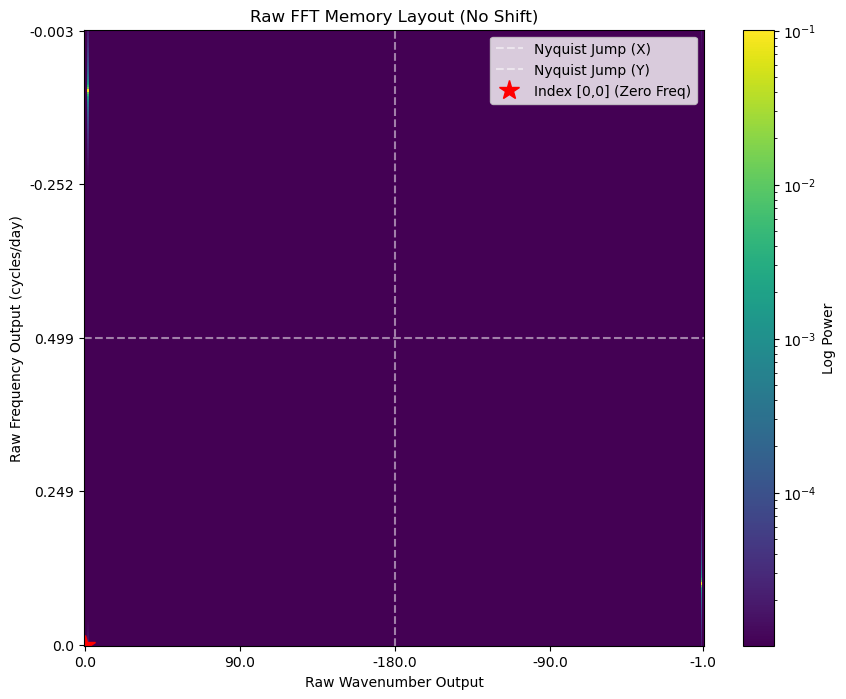

In [37]:
import numpy as np
import scipy.fft as fft
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Assuming 'field' and 'dt' are already defined in your current environment
ntime, nlon = field.shape
dt=1

# Compute the raw 2D FFT
field_hat = fft.fft2(field) / (nlon * ntime)

# Add 1e-12 to prevent log(0) from crashing the LogNorm mapping
power = np.abs(field_hat)**2 

# Calculate the raw frequencies
wavenumbers = fft.fftfreq(nlon, d=1.0) * nlon
frequencies = fft.fftfreq(ntime, d=dt)

# Calculate dynamic limits for the LogNorm based on the actual maximum power
p_max = power.max()
p_min = p_max * 1e-4 

# Create simple 1D index arrays to feed into pcolormesh
x_indices = np.arange(nlon)
y_indices = np.arange(ntime)

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
c = ax.pcolormesh(x_indices, y_indices, power, 
                  cmap='viridis', shading='nearest',
                  norm=LogNorm(vmin=p_min, vmax=p_max))

# place ticks at the start, 1/4 mark, halfway (Nyquist), 3/4 mark, and end
x_tick_idx = [0, nlon//4, nlon//2, 3*nlon//4, nlon-1]
y_tick_idx = [0, ntime//4, ntime//2, 3*ntime//4, ntime-1]

ax.set_xticks(x_tick_idx)
ax.set_xticklabels(np.round(wavenumbers[x_tick_idx], 2))

ax.set_yticks(y_tick_idx)
ax.set_yticklabels(np.round(frequencies[y_tick_idx], 3))

ax.set_title('Raw FFT Memory Layout (No Shift)')
ax.set_xlabel('Raw Wavenumber Output')
ax.set_ylabel('Raw Frequency Output (cycles/day)')

# Highlight the architecture of the raw array
ax.axvline(nlon // 2, color='white', linestyle='--', alpha=0.5, label='Nyquist Jump (X)')
ax.axhline(ntime // 2, color='white', linestyle='--', alpha=0.5, label='Nyquist Jump (Y)')
ax.plot(0, 0, 'r*', markersize=15, label='Index [0,0] (Zero Freq)')

ax.legend(loc='upper right')
fig.colorbar(c, ax=ax, label='Log Power')

plt.show()


### Why an Eastward Wave appears in the Top-Left and Bottom-Right

To understand this, we must look at how the Fourier Transform (FFT) breaks down a cosine wave into complex components and maps them to the Scipy/Numpy array indices.


### The Complex Decomposition (Euler's Formula)

The input wave is defined as:

$$\cos(kx - \omega t)$$

The FFT decomposes this into two rotating complex vectors (exponentials):

$$\cos(kx - \omega t) = \frac{1}{2}e^{j(kx - \omega t)} + \frac{1}{2}e^{-j(kx - \omega t)}$$

This creates two distinct signals in the FFT output with specific signs for $k$ and $\omega$:

* **Term A:** $e^{j(kx - \omega t)} \rightarrow$ Positive $k$, Negative $\omega$
* **Term B:** $e^{-j(kx - \omega t)} = e^{j(-kx + \omega t)} \rightarrow$ Negative $k$, Positive $\omega$


### Mapping to Raw Array Indices

In the raw output of `fft2`, indices follow the standard order: **[0, Positives, Negatives]**. Here is how those terms are placed:

* **Top-Left Signal (Term A):** $k$ is positive (first half of the X-axis), and $\omega$ is negative (second half of the Y-axis, placed in the "top" half of the raw plot).
* **Bottom-Right Signal (Term B):** $k$ is negative (second half of the X-axis, placed in the "right" side of the raw plot), and $\omega$ is positive (first half of the Y-axis, bottom of the plot).

The signal appears in the Top-Left and Bottom-Right because of the negative sign in the temporal phase of : $\cos(kx - \omega t)$.  While these "opposite" quadrants look counter-intuitive in the raw memory layout, their relationship correctly represents a constant phase moving in the positive x-direction (Eastward), we will fix this later with a flip, so Eastward is on the right.

> **Note:** If we used $\cos(kx + \omega t)$, the signal would jump to the Bottom-Left and Top-Right quadrants instead, but then negative $\omega$ would be eastward. It is a matter of nomenclature and taste.






#### FFTshift

fftshift performs a block swap to correct the orders and because the data is periodic (it wraps around), fftshift simply takes the arrays and rolls them so that the zero-frequency point is moved from the edges of the array directly to the center.

In a 2D array, it cuts the matrix into four equal quadrants and swaps them diagonally:

Top-Left (Quadrant 1) swaps with Bottom-Right (Quadrant 4).

Top-Right (Quadrant 2) swaps with Bottom-Left (Quadrant 3).

By doing this swap, the zero-zero point, which was at the top-left at index (0, 0) gets moved exactly to the middle of the matrix, creating the standard Cartesian coordinate system we are used to looking at.

In [38]:
from scipy import fft, signal

def wavenumber_freq(field,dt=1):
    """ 
    basic wavenumber frequency calculation 
    -- inputs --- 
    field(ntime,nlon) : 2d longitude time field to analyse
    dt : timestep (default = 1 unit)
    """

    # Dynamically grab the grid dimensions from the input array
    ntime, nlon = field.shape
    
    # Compute 2D FFT and normalize
    field_hat = fft.fftshift(fft.fft2(field)) / (nlon * ntime)
    power = np.abs(field_hat)**2
    
    # Calculate coordinates
    wavenumbers = fft.fftshift(fft.fftfreq(nlon, d=1.0)) * nlon
    frequencies = fft.fftshift(fft.fftfreq(ntime, d=dt))

    return power, wavenumbers, frequencies

**fft.fft2(field):** This computes the 2-Dimensional Fast Fourier Transform. It takes the  real-numbered grid of wave amplitudes and decomposes it into a grid of complex numbers. These complex numbers contain both the amplitude and the phase of every possible sine/cosine wave that can fit in the domain.

**fft.fftshift(...):** By default, standard FFT algorithms output the zero-frequency (the domain average) at the very first index (0, 0), with positive frequencies in the first half and negative frequencies wrapping around the back. fftshift mathematically rearranges the output array so that the zero-frequency/zero-wavenumber bin is placed exactly in the center of the array.

**/ (nlon * ntime):** This is the amplitude normalization. As we saw in the earlier lecture, the raw output values of a standard discrete FFT scale up with the number of grid points. By dividing by the total number of points in the 2D grid, we ensure the resulting amplitudes reflect the actual physical values of the waves, regardless of the grid resolution.

In [39]:
# calculate the fft and plot basic plot...
power, wavenumbers, frequencies = wavenumber_freq(field)

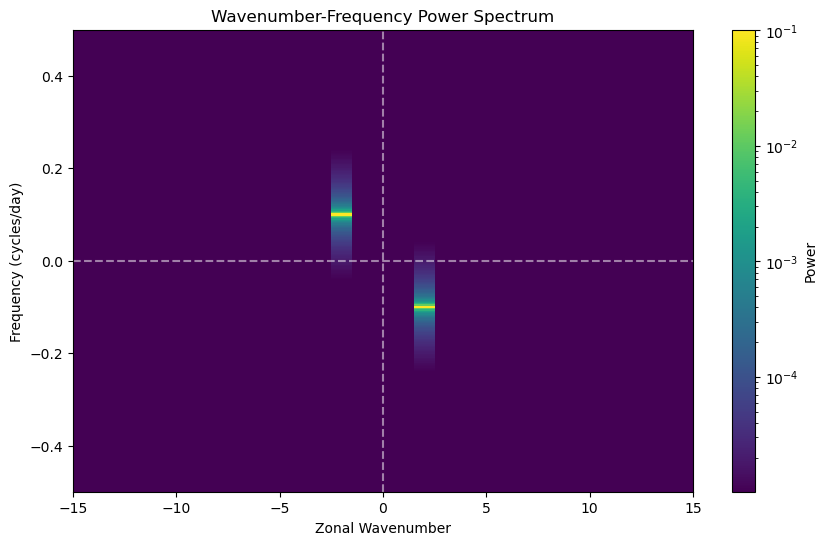

In [40]:
# Plot the Wavenumber-Frequency Spectrum
fig, ax2 = plt.subplots(1, 1, figsize=(10, 6))

# pcolormesh is usually best for spectra. 
# x-axis = wavenumbers (axis 1), y-axis = frequencies (axis 0)
# c2 = ax2.pcolormesh(wavenumbers, frequencies, power, cmap='viridis', shading='nearest')
c2 = ax2.pcolormesh(wavenumbers, frequencies, power, 
                  cmap='viridis', shading='nearest',
                  norm=LogNorm(vmin=p_min, vmax=p_max))

ax2.set_title('Wavenumber-Frequency Power Spectrum')
ax2.set_xlabel('Zonal Wavenumber')
ax2.set_ylabel('Frequency (cycles/day)')

# Zoom in on the axes to clearly see your generated wave (k=3, freq=0.1)
ax2.set_xlim(-15, 15)
ax2.set_ylim(-0.5, 0.5)

# Add lines for origin
ax2.axhline(0, color='white', linestyle='--', alpha=0.5)
ax2.axvline(0, color='white', linestyle='--', alpha=0.5)

fig.colorbar(c2, ax=ax2, label='Power')
plt.show()

### Interpreting the output 

When we generate a wave using $\cos(kx - \omega t)$, the 2D FFT will place the peaks at (+k, -freq) and (-k, +freq).  Looking at the exponents of these two terms gives you the coordinates of the peaks in the FFT spectrum:

Term 1: Has a positive spatial component ($+k$) and a negative temporal component ($-\omega$). This gives the (+3, -0.1) peak.

Term 2: Has a negative spatial component ($-k$) and a positive temporal component ($+\omega$). This gives the (-3, +0.1) peak.

Because the input array contains purely real numbers, the Fourier transform is perfectly symmetric.  Both peaks represent the exact same eastward-propagating physical wave.

So now we just need to flip the X-wavenumber axis to have eastward propagation on the right in the plot.  

We will also incorportant the factor 2 scaling on the non-zero time frequencies (as we only take +ve frequencies). 


In [41]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_wk_spectrum(field, dt=1.0, max_wavenumber=15, max_freq=0.5, title='Wavenumber-Frequency Spectrum'):
    """
    Computes and plots a Wavenumber-Frequency (Wheeler-Kiladis style) power spectrum.
    
    Parameters:
    -----------
    field : 2D numpy array
        Input data with shape (ntime, nlon).
    dt : float
        Time step between observations in days. Default is 1.0 (daily data).
    max_wavenumber : int
        Maximum zonal wavenumber to display on the x-axis.
    max_freq : float
        Maximum frequency to display on the y-axis (cycles/day).
    title : str
        Title for the plot.
        
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    
    # Slice the arrays to keep ONLY positive frequencies
    freq_zero_idx = len(frequencies) // 2
    pos_frequencies = frequencies[freq_zero_idx:]
    pos_power = power[freq_zero_idx:, :].copy()
    pos_power *= 2.0             # Double power for non-zero frequencies
    pos_power[0, :] /= 2.0       # Revert the zero-frequency (DC) bin

    # Calculate a dynamic minimum for the LogNorm so it adapts to different datasets
    p_max = pos_power.max()
    p_min = p_max * 1e-4 # Show 4 orders of magnitude 
    
    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # !!!!!!!!!!! NOTE the minus 1 !!!!!!!!!!!!!
    # Multiply wavenumbers by -1 to put Eastward on the right
    c = ax.pcolormesh(wavenumbers * -1, pos_frequencies, pos_power, 
                      cmap='viridis', shading='nearest',
                      norm=LogNorm(vmin=p_min, vmax=p_max))
    
    ax.set_title(title)
    ax.set_xlabel('Zonal Wavenumber (Westward <--- 0 ---> Eastward)')
    ax.set_ylabel('Frequency (cycles/day)')
    
    # Set the zoom limits based on function arguments
    ax.set_xlim(-max_wavenumber, max_wavenumber)
    ax.set_ylim(0, max_freq) 
    
    # Add thin reference lines
    ax.axhline(0, color='white', linestyle='--', alpha=0.3, linewidth=1)
    ax.axvline(0, color='white', linestyle='--', alpha=0.3, linewidth=1)
    
    fig.colorbar(c, ax=ax, label='Log Power')
    plt.show()
    
    return fig, ax

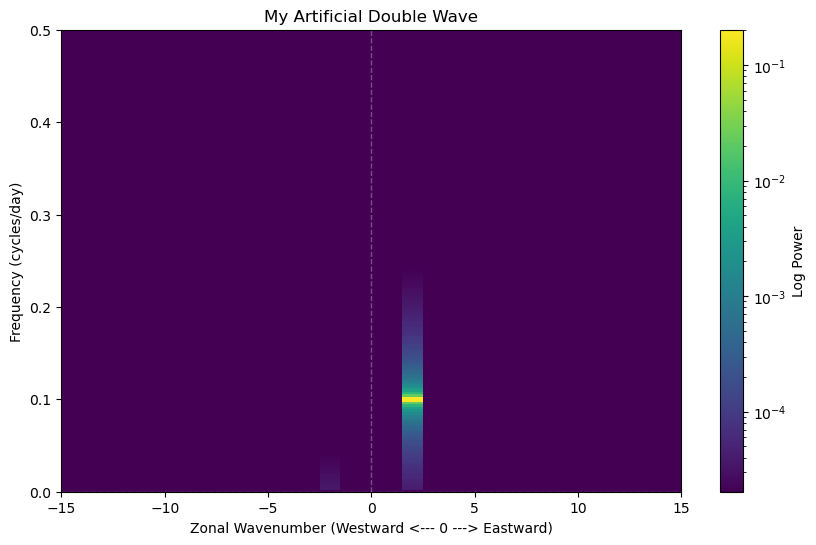

In [42]:

# Pass your generated 'field' directly into the function
fig, ax = plot_wk_spectrum(field, dt=1.0, title='My Artificial Double Wave')

</div /alert /alert-info>

Take a look at the power plot, does the peak "smear" out in the time dimension, the dequency dimension, or both?
</div>

#### Leakage vs. Spectral Ringing

While often used interchangeably in casual conversation, they are technically two different sides of the Fourier coin:

**Spectral Leakage**: A frequency-domain artifact. It happens when you truncate a signal in the time/spatial domain abruptly (especially non-integer cycles), causing the power to smear into adjacent frequency bins. (This is what you are seeing).

**Spectral Ringing (Gibbs Phenomenon)**: A time-domain artifact. It happens when you abruptly truncate a signal in the frequency domain (like applying a very harsh "brick-wall" low-pass filter) and then transform it back. It creates artificial ripples or oscillations in your physical map or time series.


The X-Direction (Longitude): Our k_zonal is 3. This means the wave completes exactly 3 full cycles across the 360-degree grid. If you loop it, the end matches the beginning perfectly. Because it fits the FFT's periodic assumption perfectly, all the power stays entirely inside the Wavenumber 3 bin.

Instead in the Y-Direction (Time): the frequency is 0.1 cycles/day, and the time series is 365 days long. This means the wave completes exactly 36.5 cycles in the temporal domain. Because it ends on a half-cycle, if we paste the end of the time series to the beginning, there is a sharp, jagged discontinuity. We already saw in the early lecture that if we do this, the FFT has to use a bunch of neighboring frequencies to mathematically recreate that sharp jump, causing the power to "leak" vertically across the frequency bins.

Now we could go back and fix the timeseries length to make sure we have exactly an integer number of cycles to test his:

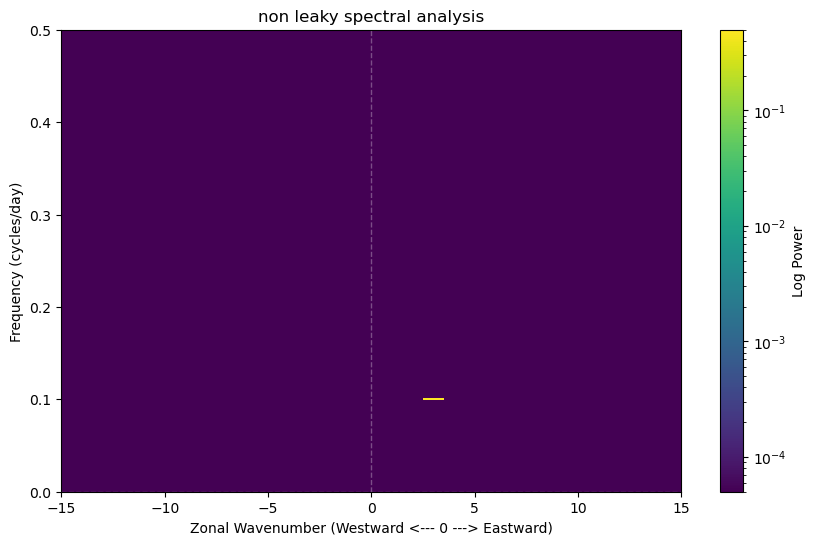

In [43]:
# Create artificial grid for a basic 2D FFT demonstration
ntime = 400 # now the frequency of 0.1 gives exactly 40 points in a cycle...
time = np.arange(ntime)
Lon, Time = np.meshgrid(lon, time)  # lon same as before 

# Wave parameters: Wavenumber 3, Frequency 0.1 cycles/day
k_zonal = 3 
freq = 0.1 
noise_amplitude=0.5

# Generate the field and add noise
field = np.cos(k_zonal * (Lon * np.pi / 180) - 2 * np.pi * freq * Time)

# calculate the fft and plot basic plot...
power, wavenumbers, frequencies = wavenumber_freq(field)

fig, ax = plot_wk_spectrum(field, dt=1.0, title='non leaky spectral analysis')

Great - the leakage is gone, but of course in reality, using real data we will never have this cyclcity. So to generalize the code we need to introduce the solution introduced in the earlier lecture and introduce the use of the *Hann window*.  Do you remember this?

Let's recreate the "leaky" example and instead now apply a windowing technique to an updated FFT function.  In the FFT lecture we imported a series of window options from the scipy package (Hann, Tukey etc), but here we demonstrate the flexible function *get_window*. The routine is written flexibility so that one can also pass a numpy array for a bespoke window if preferred (ensure the length is correct though!) 

In [44]:

from scipy.signal import get_window

def wavenumber_freq(field, dt=1, window=None):
    """ 
    Basic wavenumber frequency calculation 
    
    -- inputs --- 
    field(ntime,nlon) : 2d longitude-time field to analyse
    dt : timestep (default = 1 unit)
    window : string (e.g., 'hann', 'hamming') or 1D array, or None
    
    -- outputs ---
    power : 2D array of power
    wavenumbers : 1D array of zonal wavenumbers
    frequencies : 1D array of frequencies
    """

    ntime, nlon = field.shape
    
    if window is not None:
        # Remove the mean along the time axis to create anomalies
        field_mean = np.mean(field, axis=0)
        field_to_transform = field - field_mean
        
        # 2. Check if the user passed a string (like 'hann') or an array
        if isinstance(window, str):
            # Generate the window internally!
            win_array = get_window(window, ntime)
        else:
            # Assume the user passed their own custom 1D array
            win_array = window
            
        # 3. Reshape and apply
        window_2d = win_array[:, np.newaxis]
        field_to_transform = field_to_transform * window_2d
    else:
        field_to_transform = field

    # Compute 2D FFT and normalize
    field_hat = fft.fftshift(fft.fft2(field_to_transform)) / (nlon * ntime)
    power = np.abs(field_hat)**2
    
    # Calculate coordinates
    wavenumbers = fft.fftshift(fft.fftfreq(nlon, d=1.0)) * nlon
    frequencies = fft.fftshift(fft.fftfreq(ntime, d=dt))

    return power, wavenumbers, frequencies

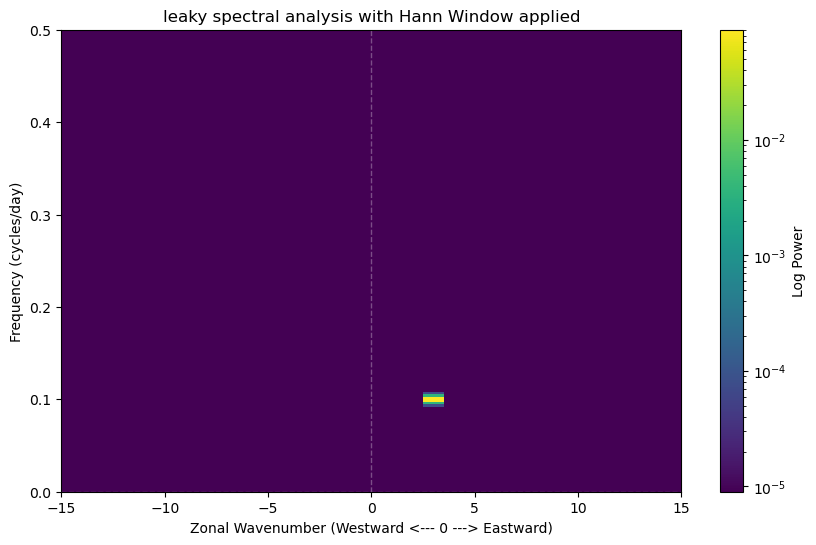

In [49]:
# Create artificial grid for a basic 2D FFT demonstration
ntime = 365 # back to the yukky one.
time = np.arange(ntime)
Lon, Time = np.meshgrid(lon, time)  # lon same as before 

# Wave parameters: Wavenumber 3, Frequency 0.1 cycles/day
k_zonal = 3 
freq = 0.1 
noise_amplitude=0.5

# Generate the field and add noise
field = np.cos(k_zonal * (Lon * np.pi / 180) - 2 * np.pi * freq * Time)

# calculate the fft and plot basic plot...
power, wavenumbers, frequencies = wavenumber_freq(field,window="hann")

fig, ax = plot_wk_spectrum(field, dt=1.0, title='leaky spectral analysis with Hann Window applied')


<div class="alert alert-block alert-info">
Exercise : change "hann" to <b>None</b>, to convince yourself that the Hann windowing is working, and also try out some other windows if you like.
</div>

Ok that was a nice clean signal - let's spice things up a bit by adding some noise...


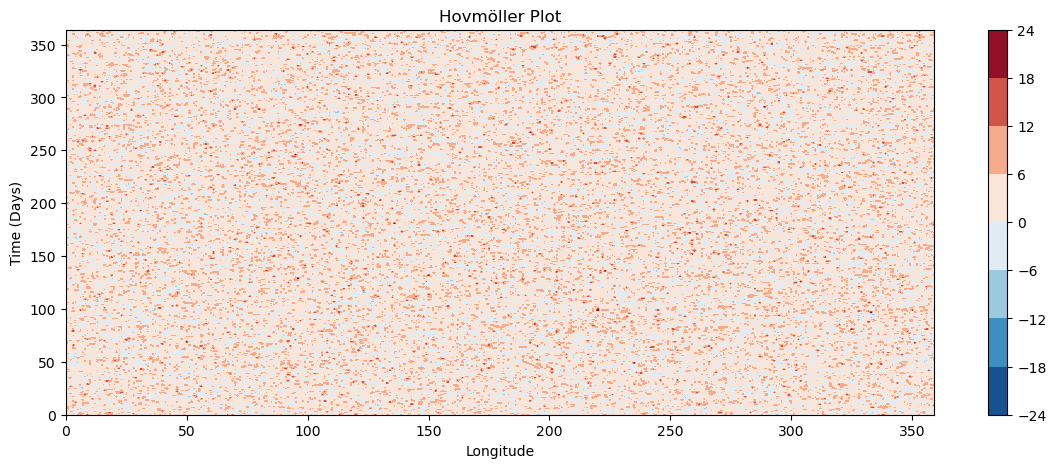

In [58]:
# Generate the field and add noise

noise_amplitude=5.0
freq=0.1
field = np.cos(k_zonal * (Lon * np.pi / 180) - 2 * np.pi * freq * Time)
field += np.random.normal(0, noise_amplitude , field.shape)

fig,ax=hovplot(field)

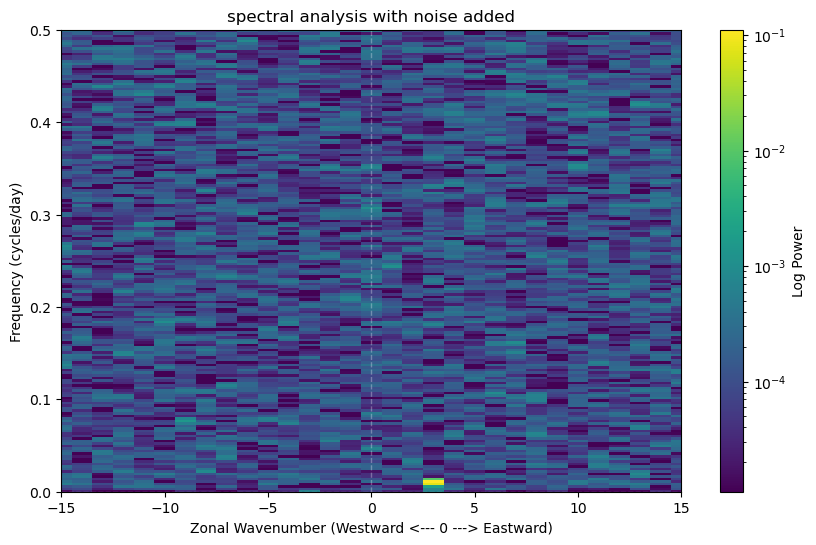

In [57]:
power, wavenumbers, frequencies = wavenumber_freq(field,window="hann")

fig, ax = plot_wk_spectrum(field, dt=1.0, title='spectral analysis with noise added')

<div class="alert alert-block alert-info">
Exercise : Scale up and down the noise amount to see how it impacts the analysis
</div>


What about if we add a second wave superimposed on the first... 

Look at the plot, can you see the two waves?


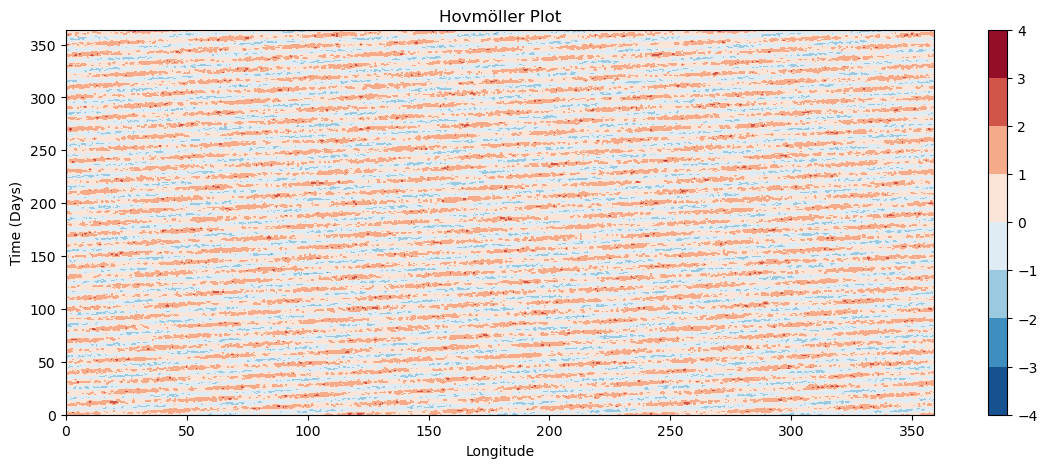

In [59]:
noise_amplitude=0.5

ratio_2nd_wave_freq=0.3
ratio_2nd_wave_lambda=3
ratio_2nd_wave_amp=0.4

# this is our same base wave 
field = np.cos(k_zonal * (Lon * np.pi / 180) - 2 * np.pi * freq * Time)

# add some noise 
field += np.random.normal(0, noise_amplitude , field.shape)

# and NOW add a second wave
field += ratio_2nd_wave_amp*np.cos(k_zonal*ratio_2nd_wave_lambda * (Lon * np.pi / 180) 
                                   - 2 * np.pi * freq*ratio_2nd_wave_freq * Time)

fig,ax=hovplot(field)

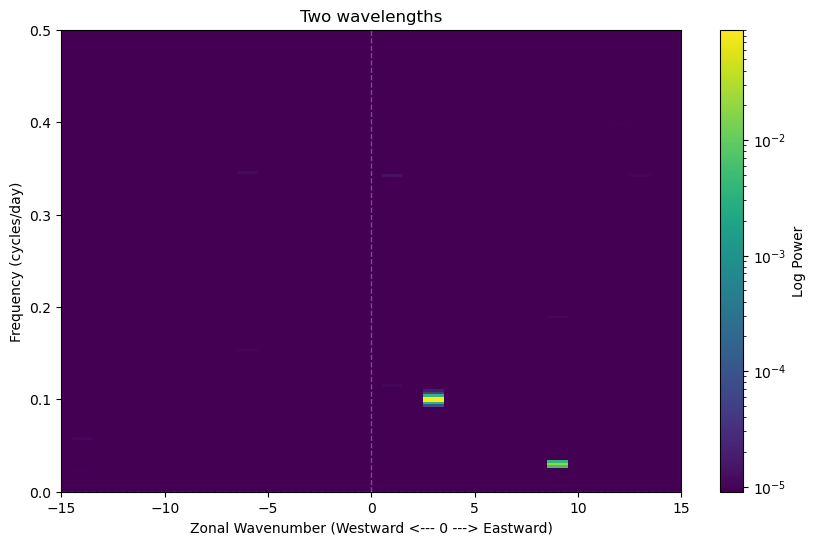

In [60]:
power, wavenumbers, frequencies = wavenumber_freq(field,window="hann")

fig, ax = plot_wk_spectrum(field, dt=1.0, title='Two wavelengths')

Are the peaks where you expect them ?

<div class="alert alert-block alert-info">
Exercise : 
    <ol>
    <li>Try changing the relative amplitudes of teh waves and the size of the noise.
    </li>
    <li>
        Make the artificial data more challenging by making the ratios a list of size N and looping over them to make a dataset made of N waves. 
    </li>
    </ol>
</div>


<div class="alert alert-block alert-info">
Mega Exercise : Download an OLR dataset, for example one year from ERA5 and try to perform a wavenumber frequency analysis of the tropics.    
</div>

STEPS:

1. Cut out the region 15S to 15N.
2. Remove the time mean
3. Remove the seasonal and diurnal cycles (you can also do this using cdo)
4. Divide into Northern and Southern hemispheres
5. Flip the order on the south side, so that the (anti)symmetric components are easy to define


In [16]:
import xarray as xr

latmax=15

### Load your dataset here:
# ds = xr.open_dataset("your_olr_data.nc")

# Subset to the Tropical Band (e.g., -15 to 15)
# Ensure your latitudes are sorted before slicing
olr = ds_olr.sel(lat=slice(-latmax, latmax))

# Remove the Long-Term Time Mean
# This removes the constant "offset" at every grid point
olr_anom = olr - olr.mean(dim='time')

# Remove the Seasonal (Annual) Cycle
# We calculate the mean for each day of the year across all years
climatology_daily = olr_anom.groupby("time.dayofyear").mean("time")
olr_anom = olr_anom.groupby("time.dayofyear") - climatology_daily

# Remove the Diurnal (Daily) Cycle
# Only necessary if data is sub-daily (e.g., 1-hourly)
# as fluxes are accumulated on ERA-I you can get daily steps, 
# but on ERA5 they are accumulated over the archive step.
diurnal_cycle = olr_anom.groupby("time.hour").mean("time")
olr_ready = olr_anom.groupby("time.hour") - diurnal_cycle

# Split into Nort)hern and Southern Hemispheres
north = tropics.sel(lat=slice(0.1, latmax))
south = tropics.sel(lat=slice(-latmax, -0.1)

# Reassign southern latitudes to match northern ones for the math
# This allows xarray to subtract/add them coordinate-wise
south_aligned = south.assign_coords(lat=north.lat.values[::-1])
north_sorted = north # Ensure it's matching the order

# Calculate Components
symmetric = 0.5 * (north_sorted + south_aligned)
antisymmetric = 0.5 * (north_sorted - south_aligned)

#...

NameError: name 'ds_olr' is not defined